# Building Neural Networks with TensorFlow: A Beginner's Guide

This notebook will guide you through the basics of building neural network (deep learning) models using TensorFlow and Keras. We'll cover dataset loading, model architecture, activation functions, layers, optimizers, evaluation, and training history visualization.

## 1. Import Required Libraries

Let's start by importing TensorFlow, Keras, NumPy, Matplotlib, and other necessary libraries.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

C:\Users\dell\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 2. Load Example Dataset from TensorFlow

We'll use the Fashion MNIST dataset, which is included in `tf.keras.datasets`. This dataset contains 70,000 grayscale images of 10 fashion categories.

In [2]:
# Load Fashion MNIST dataset
fashion_mnist = keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


## 3. Preprocess the Data

Neural networks work best when input data is normalized. We'll scale the pixel values to the range [0, 1] and reshape the data for the network.

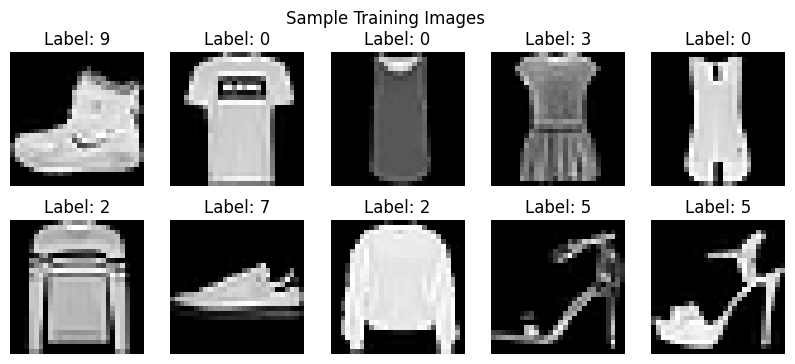

In [12]:
# Show some training samples
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.suptitle("Sample Training Images")
plt.show()

In [3]:
# Normalize pixel values
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Reshape for dense layers (flatten images)
X_train_flat = X_train.reshape(-1, 28 * 28)
X_test_flat = X_test.reshape(-1, 28 * 28)

print("Flattened training data shape:", X_train_flat.shape)

Flattened training data shape: (60000, 784)


## 4. Build a Neural Network Model (Sequential API)

Let's create a basic neural network using Keras' Sequential API. We'll start with one hidden layer.

In [5]:
# Basic Sequential model
model = keras.Sequential([
    layers.Input(shape=(28*28,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 128)               100480    
                                                                 
 dense_3 (Dense)             (None, 10)                1290      
                                                                 
Total params: 101770 (397.54 KB)
Trainable params: 101770 (397.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## 5. Experiment with Different Activation Functions

Activation functions introduce non-linearity to the network. Let's see how to use different activations like `relu`, `sigmoid`, and `tanh`.

In [6]:
# Example: Using different activation functions
model_relu = keras.Sequential([
    layers.Input(shape=(28*28,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_sigmoid = keras.Sequential([
    layers.Input(shape=(28*28,)),
    layers.Dense(128, activation='sigmoid'),
    layers.Dense(10, activation='softmax')
])

model_tanh = keras.Sequential([
    layers.Input(shape=(28*28,)),
    layers.Dense(128, activation='tanh'),
    layers.Dense(10, activation='softmax')
])

## 6. Vary the Number of Layers and Neurons

You can experiment by changing the number of hidden layers and neurons. Let's try a deeper network.

In [7]:
# Deeper network with more neurons
deep_model = keras.Sequential([
    layers.Input(shape=(28*28,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

deep_model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_10 (Dense)            (None, 256)               200960    
                                                                 
 dense_11 (Dense)            (None, 128)               32896     
                                                                 
 dense_12 (Dense)            (None, 64)                8256      
                                                                 
 dense_13 (Dense)            (None, 10)                650       
                                                                 
Total params: 242762 (948.29 KB)
Trainable params: 242762 (948.29 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## 7. Compile the Model with Different Optimizers

Keras supports various optimizers. Let's compile the model with SGD, Adam, and RMSprop.

In [8]:
# Compile with SGD optimizer
model.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Compile with Adam optimizer
model_relu.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# Compile with RMSprop optimizer
model_sigmoid.compile(optimizer='rmsprop',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

## 8. Train the Model and Record History

Let's fit the model to the training data and store the training history for analysis.

In [9]:
# Train the model and save history
history = model.fit(
    X_train_flat, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10


1500/1500 [==============================] - 9s 5ms/step - loss: 0.7728 - accuracy: 0.7541 - val_loss: 0.5778 - val_accuracy: 0.8052
Epoch 2/10
1500/1500 [==============================] - 7s 4ms/step - loss: 0.5306 - accuracy: 0.8213 - val_loss: 0.4995 - val_accuracy: 0.8256
Epoch 3/10
1500/1500 [==============================] - 7s 5ms/step - loss: 0.4808 - accuracy: 0.8363 - val_loss: 0.4659 - val_accuracy: 0.8368
Epoch 4/10
1500/1500 [==============================] - 7s 5ms/step - loss: 0.4539 - accuracy: 0.8428 - val_loss: 0.4482 - val_accuracy: 0.8442
Epoch 5/10
1500/1500 [==============================] - 7s 5ms/step - loss: 0.4365 - accuracy: 0.8481 - val_loss: 0.4553 - val_accuracy: 0.8424
Epoch 6/10
1500/1500 [==============================] - 6s 4ms/step - loss: 0.4216 - accuracy: 0.8529 - val_loss: 0.4278 - val_accuracy: 0.8482
Epoch 7/10
1500/1500 [==============================] - 8s 5ms/step - loss: 0.4098 - accuracy: 0.8582 - val_loss: 0.4094 - val_accurac

## 9. Evaluate Model Performance

Evaluate the trained model on the test set and print metrics such as accuracy and loss.

In [10]:
# Evaluate on test data
test_loss, test_acc = model.evaluate(X_test_flat, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

313/313 - 1s - loss: 0.4366 - accuracy: 0.8448 - 1s/epoch - 4ms/step
Test accuracy: 0.8448
Test loss: 0.4366


313/313 [==============================] - 1s 3ms/step
Classification               precision    recall  f1-score   support

           0       0.78      0.85      0.81      1000
           1       0.98      0.96      0.97      1000
           2       0.78      0.72      0.75      1000
           3       0.81      0.90      0.85      1000
           4       0.84      0.60      0.70      1000
           5       0.95      0.94      0.94      1000
           6       0.58      0.65      0.62      1000
           7       0.91      0.93      0.92      1000
           8       0.92      0.96      0.94      1000
           9       0.94      0.94      0.94      1000

    accuracy                           0.84     10000
   macro avg       0.85      0.84      0.84     10000
weighted avg       0.85      0.84      0.84     10000



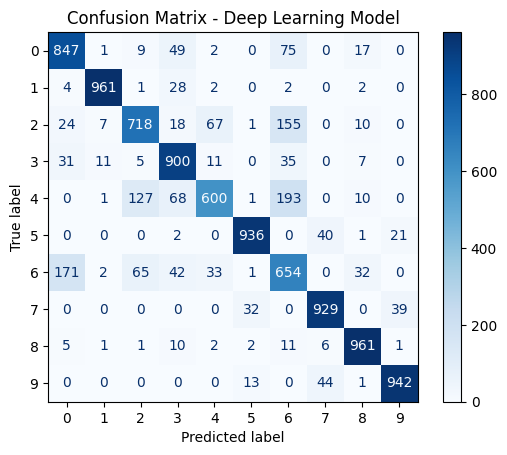

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,classification_report

# Predict labels for the test set using the deep model
y_pred_deep = np.argmax(model.predict(X_test_flat), axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_deep)
print("Classification",classification_report(y_test, y_pred_deep))

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Deep Learning Model")
plt.show()

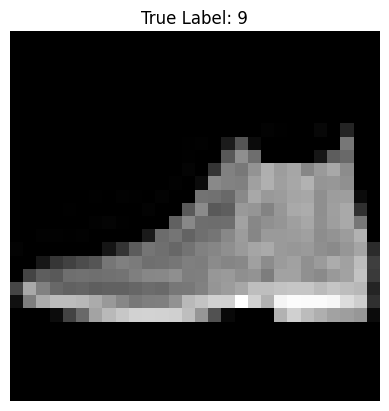

1/1 [==============================] - 0s 59ms/step
Model Prediction: 9


In [14]:
# Show a test sample before prediction
sample_idx = 0  # You can change this index to see different samples
plt.imshow(X_test[sample_idx], cmap='gray')
plt.title(f"True Label: {y_test[sample_idx]}")
plt.axis('off')
plt.show()

# Predict the label for this sample
sample_flat = X_test_flat[sample_idx].reshape(1, -1)
pred_label = np.argmax(model.predict(sample_flat), axis=1)[0]
print(f"Model Prediction: {pred_label}")

## 10. Visualize Training History

Plot the training and validation loss and accuracy curves using Matplotlib.

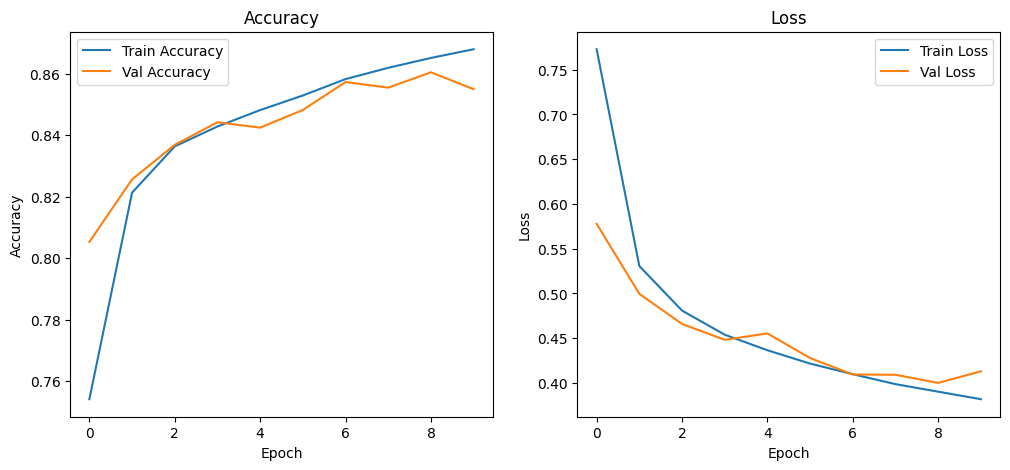

In [11]:
# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Training data shape: (404, 13)
Test data shape: (102, 13)
Epoch 1/50
21/21 [==============================] - 3s 22ms/step - loss: 397.6538 - mae: 15.7052 - val_loss: 118.1858 - val_mae: 8.6487
Epoch 2/50
21/21 [==============================] - 0s 8ms/step - loss: 132.5575 - mae: 9.3208 - val_loss: 107.8957 - val_mae: 7.8411
Epoch 3/50
21/21 [==============================] - 0s 6ms/step - loss: 114.8633 - mae: 8.2661 - val_loss: 122.4263 - val_mae: 8.0932
Epoch 4/50
21/21 [==============================] - 0s 9ms/step - loss: 89.7338 - mae: 7.1877 - val_loss: 83.6876 - val_mae: 7.0068
Epoch 5/50
21/21 [==============================] - 0s 9ms/step - loss: 76.0200 - mae: 6.5561 - val_loss: 91.4229 - val_mae: 6.6231
Epoch 6/50
21/21 [==============================] - 0s 5ms/step - loss: 65.2829 - mae: 5.9002 - val_loss: 77.6312 - val_mae: 6.1823
Epoch 7/50
21/21 [==============================] - 0s 7ms/step - loss: 61.4521 - mae: 5.8120 - val_loss: 72.8467 - val_mae: 5.9683
Epoch 8/50

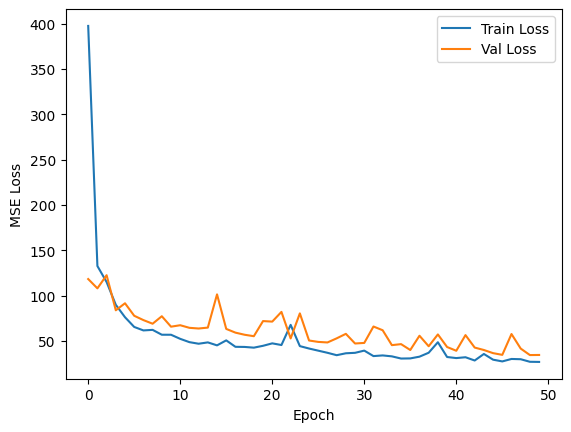

In [22]:
# Example: Regression with Keras on Boston Housing dataset

from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Load the Boston Housing dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.boston_housing.load_data()

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

# Build a simple regression model
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1,activation="linear")  # Output layer for regression
])

model.compile(
    optimizer='adam',
    loss='mse',  # Mean Squared Error for regression
    metrics=['mae']  # Mean Absolute Error as an additional metric
)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# Evaluate the model
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=2)
print(f"Test MAE: {test_mae:.2f}")

# Plot training & validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()